# Warm-Started Alpha Sweep

This notebook demonstrates how to run a **warm-started** angle of attack (alpha) sweep. In this setup, each next case is initialized from the previous alpha solution rather than from freestream. This is achieved using the `fork_from` argument of `project.run_case()`. Warm-starting can produce more accurate results especially for conditions close to separation, as RANS simulations often get stuck in topological flow phenomena. With an initial condition closer to the final result, warm-starting reduces the formation of non-physical separation patterns during the convergence history. Each case also uses a custom **stopping criterion** on `CL` so the solver exits as soon as convergence is reached rather than always running to `max_steps`.

The example uses the built-in `Airplane` geometry with the new mesher. After all cases finish we build a pandas `DataFrame` of time-averaged `CL` and `CD` values taken from `results.total_forces` using its `get_averages()` helper and plot the standard aerodynamic curves: `CL` vs `AoA`, `CD` vs `AoA` and the drag polar (`CL` vs `CD`).

## 1. Setup and Imports

We import `flow360` for everything related to project and case management, `pandas` for the post-processing dataframe and `matplotlib` to display the plots produced by pandas.

In [1]:
import flow360 as fl
from flow360.examples import Airplane

import pandas as pd
import matplotlib.pyplot as plt

## 2. Project Creation

A Flow360 `Project` holds the geometry asset as well as every mesh and case derived from it. We initialise the project directly from the `Airplane` example geometry.

In [2]:
Airplane.get_files()

project = fl.Project.from_geometry(
    Airplane.geometry,
    name="Warm-Started Alpha Sweep",
)

geometry = project.geometry

[22:22:10] INFO: Geometry successfully submitted:                                                                  
                   type        = Geometry                                                                          
                   name        = Warm-Started Alpha Sweep                                                          
                   id          = geo-37a2ec12-19c3-4cee-b210-e473c6f616d2                                          
                   status      = uploaded                                                                          
                   project id  = prj-9ea5207f-0689-4f81-a46d-dae5f6a463f2                                          
           

           INFO: Waiting for geometry to be processed.

## 3. Meshing Parameters

Showcasing meshing is not a goal of this tutorial, so we keep the configuration minimal:

- a first boundary-layer cell thickness and a single `surface_max_edge_length` in `MeshingDefaults`,
- a single `AutomatedFarfield` volume zone that generates the outer farfield for us.

The new mesher is selected later on by passing `use_beta_mesher=True` to `project.run_case()`.

In [3]:
with fl.SI_unit_system:
    far_field_zone = fl.AutomatedFarfield()

    meshing_params = fl.MeshingParams(
        defaults=fl.MeshingDefaults(
            boundary_layer_first_layer_thickness=0.01 * fl.u.mm,
            surface_max_edge_length=0.2,
        ),
        volume_zones=[far_field_zone],
    )

[22:22:39] INFO: using: SI unit system for unit inference.

## 4. Simulation Parameters

We build one `SimulationParams` object that will be reused for every case in the sweep. The only field we will modify between runs is `operating_condition.alpha`, which the loop below overwrites on each iteration.

To let the solver finish as soon as each case has settled, we attach a `RunControl` with a `StoppingCriterion` that watches `CL`: once the coefficient stays within a tolerance of `0.05` over a window of `200` pseudo-steps the run is terminated, even if `max_steps` has not been reached. A matching `ForceOutput` on the airplane walls exposes `CL` as a monitored output so the stopping criterion has a field to watch. The residual tolerances are loosened so that the force convergence is the main condition for stopping the simulation (all criteria, including the solver tolerances must be met for the case to stop).

> **Note:** A `CL` tolerance of `0.05` is deliberately generous and is used here only for demonstration purposes so the cases finish quickly. For production runs you would typically pick a much tighter value matched to the accuracy you actually need.

In [4]:
with fl.SI_unit_system:
    walls =fl.Wall(surfaces=[geometry["*"]])
    cl_output = fl.ForceOutput(
        output_fields=["CL"],
        models=[walls]
    )
    params = fl.SimulationParams(
        meshing=meshing_params,
        reference_geometry=fl.ReferenceGeometry(),
        operating_condition=fl.AerospaceCondition(
            velocity_magnitude=100,
            alpha=0 * fl.u.deg,
        ),
        time_stepping=fl.Steady(max_steps=4000),
        models=[
            walls,
            fl.Freestream(surfaces=[far_field_zone.farfield]),
            fl.Fluid(
                navier_stokes_solver=fl.NavierStokesSolver(
                    absolute_tolerance=1e-5
                ),
                turbulence_model_solver=fl.SpalartAllmaras(
                    absolute_tolerance=1e-5
                )
            )
        ],
        outputs=[cl_output],
        run_control=fl.RunControl(
            stopping_criteria=[
                fl.StoppingCriterion(
                    monitor_field="CL",
                    monitor_output=cl_output,
                    tolerance=0.05,
                    tolerance_window_size=200
                )
            ]
        )
    )

           INFO: using: SI unit system for unit inference.

## 5. Running the Sweep

We iterate through the list of alphas, updating `params.operating_condition.alpha` in place on every iteration and submitting a case via `project.run_case()`. The very first case is a regular cold-start run (no `fork_from`); for every subsequent alpha we pass `fork_from=previous_case`, which tells the platform to initialise the flow field from the previous alpha's final solution instead of from uniform freestream.

We do **not** need to wait for each case to finish before submitting the next: Flow360 will schedule the forked cases on the cloud and start each of them as soon as its parent has produced a restart file. This lets us submit the whole sweep in one pass and then wait once at the end.

In [5]:
alphas = [-4, 0, 4, 8, 12] * fl.u.deg

case_list = []
previous_case = None

for alpha_angle in alphas:
    params.operating_condition.alpha = alpha_angle

    if alpha_angle == alphas[0]:
        # First case: cold-start from uniform freestream.
        case = project.run_case(
            params=params,
            name=f"alpha_{alpha_angle.value}",
            use_beta_mesher=True,
        )
    else:
        # Subsequent cases: warm-start by forking from the previous alpha.
        case = project.run_case(
            params=params,
            name=f"alpha_{alpha_angle.value}",
            fork_from=previous_case,
            use_beta_mesher=True,
        )

    previous_case = case

    print(f"Submitted {case.name} (id: {case.id})")
    case_list.append((alpha_angle, case))

print("Waiting for all cases to finish...")
for _, case in case_list:
    case.wait()
print("All cases completed.")

[22:22:40] INFO: Selecting beta/in-house mesher for possible meshing tasks.

[22:22:43] INFO: Successfully submitted:                                                                           
                   type        = Case                                                                              
                   name        = alpha_-4                                                                          
                   id          = case-cae6ebfa-19de-429c-86e0-544fe70dd03c                                         
                   status      = pending                                                                           
                   project id  = prj-9ea5207f-0689-4f81-a46d-dae5f6a463f2                                          
           

Submitted alpha_-4 (id: case-cae6ebfa-19de-429c-86e0-544fe70dd03c)


[22:22:44] INFO: Selecting beta/in-house mesher for possible meshing tasks.

[22:22:46] INFO: Successfully submitted:                                                                           
                   type        = Case                                                                              
                   name        = alpha_0                                                                           
                   id          = case-fd96b8ec-90f0-492a-a012-63127281cdc8                                         
                   status      = pending                                                                           
                   project id  = prj-9ea5207f-0689-4f81-a46d-dae5f6a463f2                                          
           

...

Submitted alpha_8 (id: case-36c5179c-4c25-4f82-8dfa-aa8c42b0bb71)


[22:22:53] INFO: Selecting beta/in-house mesher for possible meshing tasks.

[22:22:55] INFO: Successfully submitted:                                                                           
                   type        = Case                                                                              
                   name        = alpha_12                                                                          
                   id          = case-af2bd93e-4855-447c-abfe-9dab43855d9e                                         
                   status      = pending                                                                           
                   project id  = prj-9ea5207f-0689-4f81-a46d-dae5f6a463f2                                          
           

Submitted alpha_12 (id: case-af2bd93e-4855-447c-abfe-9dab43855d9e)
Waiting for all cases to finish...


All cases completed.


## 6. Post-Processing

With the sweep finished we collect averaged total force coefficients from each case. `case.results.total_forces` exposes a `get_averages(fraction)` helper that returns the mean of the last `fraction` of pseudo-steps as a pandas `Series`, so we can index directly into it to obtain the converged `CL` and `CD`.

In [6]:
records = []
for alpha_angle, case in case_list:
    averages = case.results.total_forces.get_averages(0.1)
    records.append(
        {
            "alpha_deg": float(alpha_angle.to("deg").value),
            "CL": averages["CL"],
            "CD": averages["CD"],
        }
    )

sweep = pd.DataFrame(records).sort_values("alpha_deg").reset_index(drop=True)
print(sweep)

[23:00:09] INFO: Saved to C:\Users\Piotr\AppData\Local\Temp\tmpz_p_3h1s\ccb1d2ec-769a-415f-963e-ab4107915615.csv

[23:00:12] INFO: Saved to C:\Users\Piotr\AppData\Local\Temp\tmpz_p_3h1s\55abf9de-19a6-4fea-affe-4ef66a558c3d.csv

[23:00:14] INFO: Saved to C:\Users\Piotr\AppData\Local\Temp\tmpz_p_3h1s\d1c7d713-bc47-40cc-8b05-45d14f6f9dd2.csv

[23:00:16] INFO: Saved to C:\Users\Piotr\AppData\Local\Temp\tmpz_p_3h1s\ca7c651e-efdf-4b34-ad14-61f8fa17a772.csv

[23:00:19] INFO: Saved to C:\Users\Piotr\AppData\Local\Temp\tmpz_p_3h1s\9b311da0-e62c-42ca-b8f9-e0d6f0069fb0.csv

   alpha_deg         CL        CD
0       -4.0  -4.623297  0.266586
1        0.0   1.617527  0.195803
2        4.0   7.870213  0.395486
3        8.0  14.101717  0.982705
4       12.0  18.091709  2.830544


### CL vs AOA, CD vs AOA and the drag polar

Pandas' built-in `DataFrame.plot()` is convenient for quick engineering plots. We produce three panels: the lift curve, the drag curve and the drag polar.

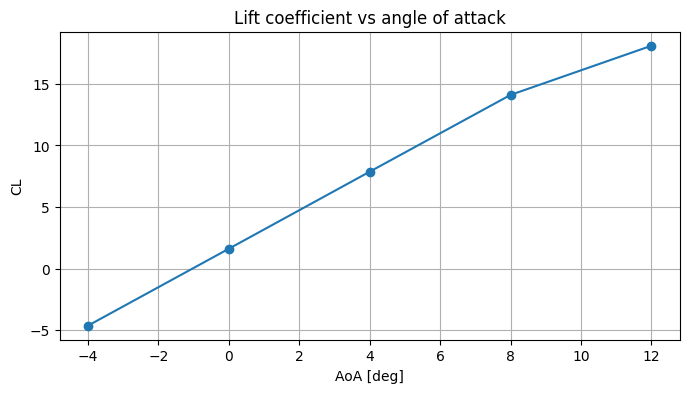

In [7]:
ax = sweep.plot(
    x="alpha_deg",
    y="CL",
    marker="o",
    legend=False,
    xlabel="AoA [deg]",
    ylabel="CL",
    title="Lift coefficient vs angle of attack",
    figsize=(8, 4),
)
ax.grid(True)
plt.show()

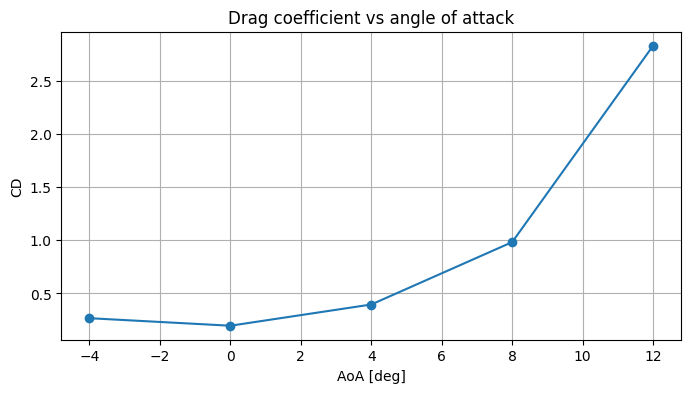

In [8]:
ax = sweep.plot(
    x="alpha_deg",
    y="CD",
    marker="o",
    legend=False,
    xlabel="AoA [deg]",
    ylabel="CD",
    title="Drag coefficient vs angle of attack",
    figsize=(8, 4),
)
ax.grid(True)
plt.show()

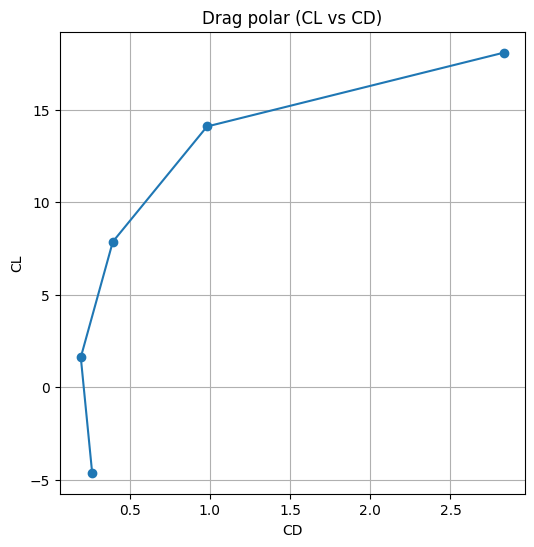

In [9]:
ax = sweep.plot(
    x="CD",
    y="CL",
    marker="o",
    legend=False,
    xlabel="CD",
    ylabel="CL",
    title="Drag polar (CL vs CD)",
    figsize=(6, 6),
)
ax.grid(True)
plt.show()